# Daily Challenge: Interactive Data Visualization with Matplotlib and Seaborn

## 1. Data Preparation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px

df = pd.read_excel('DA_Marketing_Strategy/US_Superstore_data.xls')

# Extract year from Order Date
df['Year'] = df['Order Date'].dt.year

# The dataset is US-only — country column is always 'United States'
# We'll use State as the geographic dimension for the map
print('Shape:', df.shape)
print('Years:', sorted(df['Year'].unique()))
print('Countries:', df['Country'].unique())
print('Missing values:', df.isnull().sum().sum())
df.head(3)

Shape: (9994, 22)
Years: [2014, 2015, 2016, 2017]
Countries: ['United States']
Missing values: 0


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136,2016
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820,2016
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714,2016


## 2. Sales Trend Over the Years

Static line chart with annotated values and a shaded area under the curve.

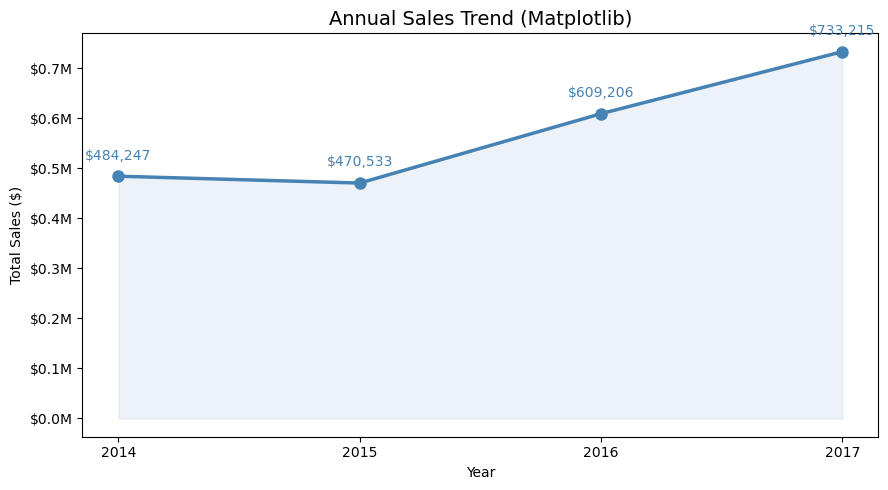

Sales grew 51.4% from 2014 to 2017.


In [3]:
yearly_sales = df.groupby('Year')['Sales'].sum()

plt.figure(figsize=(9, 5))
plt.plot(yearly_sales.index, yearly_sales.values,
         marker='o', linewidth=2.5, markersize=8, color='steelblue')
plt.fill_between(yearly_sales.index, yearly_sales.values, alpha=0.1, color='steelblue')

for year, val in yearly_sales.items():
    plt.annotate(f'${val:,.0f}', xy=(year, val),
                 xytext=(0, 12), textcoords='offset points',
                 ha='center', fontsize=10, color='steelblue')

plt.title('Annual Sales Trend (Matplotlib)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Total Sales ($)')
plt.xticks(yearly_sales.index)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

growth = (yearly_sales.iloc[-1] - yearly_sales.iloc[0]) / yearly_sales.iloc[0] * 100
print(f'Sales grew {growth:.1f}% from {yearly_sales.index[0]} to {yearly_sales.index[-1]}.')

## 3. Interactive Line Chart: Sales Trend

Same trend data but interactive — hover to see exact values, zoom, and pan.

In [4]:
yearly_df = yearly_sales.reset_index()
yearly_df.columns = ['Year', 'Sales']

fig = px.line(
    yearly_df, x='Year', y='Sales',
    markers=True,
    title='Annual Sales Trend (Plotly — Interactive)',
    labels={'Sales': 'Total Sales ($)', 'Year': 'Year'},
    color_discrete_sequence=['steelblue']
)
fig.update_traces(line=dict(width=3), marker=dict(size=10))
fig.update_layout(hovermode='x unified')
fig.show()

## 4. Interactive Map: Sales by State

Since the dataset is US-only, we map sales at the **state** level using a choropleth map.

In [5]:
state_sales = df.groupby('State')['Sales'].sum().reset_index()

fig = px.choropleth(
    state_sales,
    locations='State',
    locationmode='USA-states',
    color='Sales',
    scope='usa',
    color_continuous_scale='Blues',
    title='Sales Distribution by State (Plotly — Interactive)',
    labels={'Sales': 'Total Sales ($)'}
)
fig.show()

## 5. Top 10 Products by Sales

Clean horizontal bar chart. Product names are truncated for readability.

C:\Users\hp\AppData\Local\Temp\ipykernel_21380\938589170.py:11: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




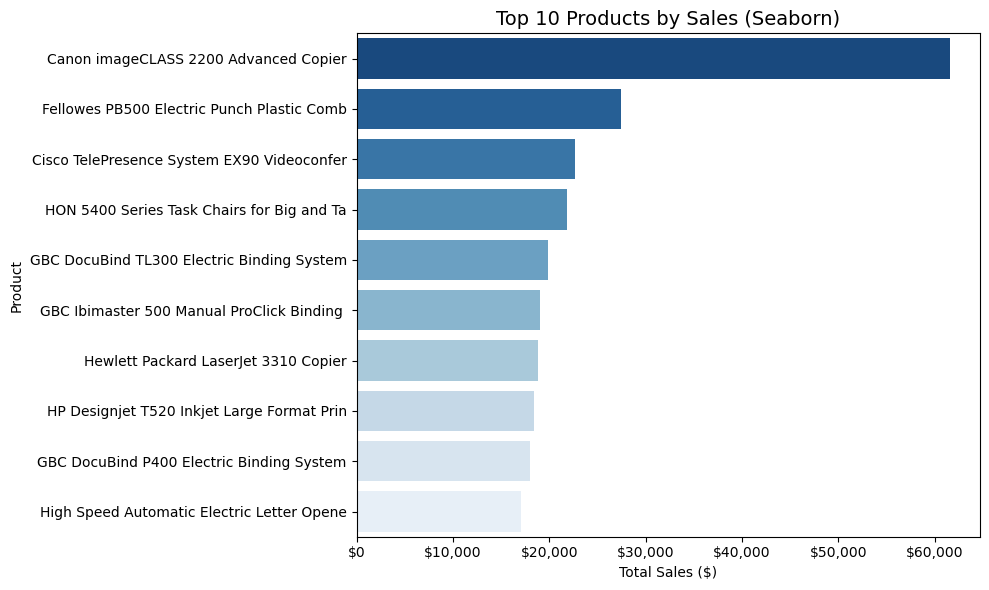

Top product: Canon imageCLASS 2200 Advanced Copier


In [6]:
top10 = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top10['Short Name'] = top10['Product Name'].str[:42]

plt.figure(figsize=(10, 6))
sns.barplot(data=top10, x='Sales', y='Short Name', palette='Blues_r')
plt.title('Top 10 Products by Sales (Seaborn)', fontsize=14)
plt.xlabel('Total Sales ($)')
plt.ylabel('Product')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

print('Top product:', top10.iloc[0]['Product Name'])

## 6. Profit vs Discount

Scatter plot with a regression trend line overlaid. The red horizontal line marks the break-even point (profit = 0).

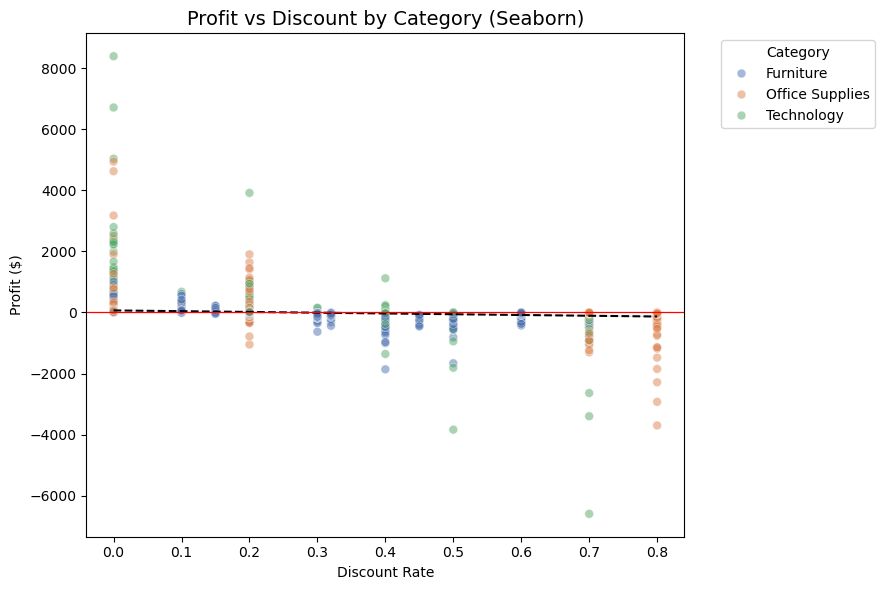

Correlation — Discount vs Profit: -0.219
Insight: Discounts above ~40% almost always result in losses.


In [7]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df, x='Discount', y='Profit',
    hue='Category', palette='deep', alpha=0.5, s=40
)
sns.regplot(
    data=df, x='Discount', y='Profit',
    scatter=False, color='black',
    line_kws={'linewidth': 1.5, 'linestyle': '--'}
)
plt.axhline(0, color='red', linewidth=0.9)
plt.title('Profit vs Discount by Category (Seaborn)', fontsize=14)
plt.xlabel('Discount Rate')
plt.ylabel('Profit ($)')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

corr = df['Discount'].corr(df['Profit'])
print(f'Correlation — Discount vs Profit: {corr:.3f}')
print('Insight: Discounts above ~40% almost always result in losses.')

## 7. Comparative Analysis

| Aspect | Matplotlib | Plotly | Seaborn |
|--------|-----------|--------|--------|
| **Interactivity** | ❌ Static | ✅ Hover, zoom, pan | ❌ Static |
| **Maps** | ❌ Not built-in | ✅ Choropleth built-in | ❌ Not built-in |
| **Code length** | More verbose | Medium | Least code |
| **Statistical plots** | Manual | Manual | Built-in (KDE, regression) |
| **Best for** | Custom static charts | Interactive & geographic | Statistical analysis |

**Key Findings:**
- Sales grew steadily each year — strongest jump between 2015 and 2016.
- California and New York account for the darkest regions on the map — highest sales concentration.
- Top products are high-ticket technology items (phones, copiers, machines).
- Discount rate and profit have a strong **negative correlation (~−0.22)** — heavy discounting destroys margins.